In [ ]:
# AIM OF PROJECT

# The aim of this project is to develop a multiple linear regression model that predicts employee salaries based on demographic
# and employment-related factors, including tenure, number of internal moves, gender, and job position. The project applies  
# Exploratory Data Analysis, Data preprocessing, Feature Engineering and Regression modelling techniques to identify the variables
# that significantly influence salary and evaluate the predictive performance of the model.Through this analysis I demonstrate 
# end-to-end process of building and interpreting a machine learning model for a business problem using Python.

In [1]:
# 1. Import relevant libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
sns.set()

In [2]:
data=pd.read_csv("C:/Users/Lenovo/Downloads/hr_data salary pred.csv")

In [3]:
data.head()

,Emp_no,First_Name,Gender,Tenure_years,Position,No.of Moves,Annual Salary
0,10001,Georgi,M,18.414784,Senior Engineer,0,88958
1,10002,Bezalel,F,19.008898,Staff,0,72527
2,10016,Kazuhito,M,9.826146,Staff,0,77935
3,10017,Cristinel,F,11.310061,Senior Staff,1,99651
4,10018,Kazuhide,F,17.645448,Senior Engineer,0,84672


In [4]:
# Check for problems with data 

data.describe(include='all')

,Emp_no,First_Name,Gender,Tenure_years,Position,No.of Moves,Annual Salary
count,240125.000000,240125,240125,240125.000000,240125,240125.000000,240125.000000
unique,NaN,1275,2,NaN,7,NaN,NaN
top,NaN,Shahab,M,NaN,Senior Engineer,NaN,NaN
freq,NaN,241,144115,NaN,85939,NaN,NaN
mean,253079.603144,NaN,NaN,14.818072,NaN,0.137653,72012.286484
std,161853.510344,NaN,NaN,3.521748,NaN,0.344536,17309.977114
min,10001.000000,NaN,NaN,4.837782,NaN,0.000000,38623.000000
25%,84878.000000,NaN,NaN,12.317590,NaN,0.000000,59049.000000
50%,249792.000000,NaN,NaN,15.425051,NaN,0.000000,69805.000000
75%,424895.000000,NaN,NaN,17.790554,NaN,0.000000,82546.000000


In [5]:
# It's all good here,there doesn't seem to be any problem with the data

# From the unique row, we see there are 7 unique positions, and 2 unique Gender. I will assign dummy variables to these 2 
# categorical variables later.

# I'll go ahead and drop the 'Emp_no' and 'First_Name' variables as they're not needed.

In [6]:
data_upd = data.drop(columns=['Emp_no', 'First_Name'])
data_upd.describe(include='all')

,Gender,Tenure_years,Position,No.of Moves,Annual Salary
count,240125,240125.000000,240125,240125.000000,240125.000000
unique,2,NaN,7,NaN,NaN
top,M,NaN,Senior Engineer,NaN,NaN
freq,144115,NaN,85939,NaN,NaN
mean,NaN,14.818072,NaN,0.137653,72012.286484
std,NaN,3.521748,NaN,0.344536,17309.977114
min,NaN,4.837782,NaN,0.000000,38623.000000
25%,NaN,12.317590,NaN,0.000000,59049.000000
50%,NaN,15.425051,NaN,0.000000,69805.000000
75%,NaN,17.790554,NaN,0.000000,82546.000000


In [7]:
# Now that I have the snapshot of data and there's no missing values, I'll check for other problems that may arise.


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Annual Salary', ylabel='Density'>

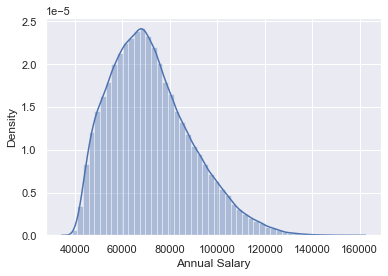

In [8]:
# I'll print the Probability Distribution Functions of the Features using Seaborn

sns.distplot(data_upd['Annual Salary'])

In [9]:
# look at its Descriptives...
# Price has a MEAN of $72k
# MIN of $38k
# 25% of prices are UNDER $60k
# 50% of prices are BELOW $70,500, 75% are lower than $83k while the MAX is $158k. There are no outliers in the 'salary' numbers

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Tenure_years', ylabel='Density'>

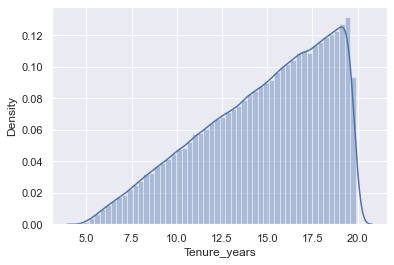

In [10]:
# Next, we'll print the PDF for Tenure

sns.distplot(data_upd['Tenure_years'])

In [11]:
# I'll check the relationship between salary and tenure

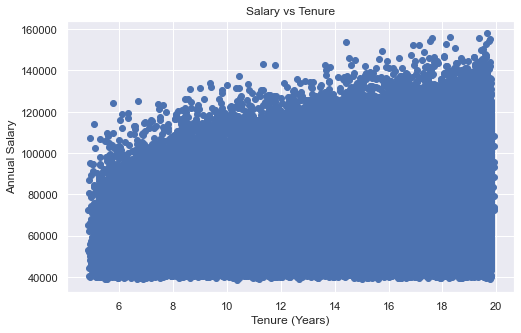

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(
    data_upd['Tenure_years'],
    data_upd['Annual Salary'])

plt.title('Salary vs Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Annual Salary')

plt.show()

In [ ]:
# Looking at this scatterplot, there is a positive relationship between tenure & salary: And we can make further observations
#1 As tenure increases, the upper range of salaries tends to increase
#2 Employees with longer tenure generally have access to higher salaries.
#3 The trend appears broadly upward rather than completely random.

In [ ]:
# However there are 2 important observations.
#1 The relationship is not very tight: for e.g, around 15 years of tenure, salaries range from roughly: 40,000 - 150,000.This is a 
# huge spread.This means that there are other factors influencing salary.

#2 The fan-shape is interesting. 5 years tenure -> smaller salary range. 20 years tenure -> much larger salary range.
# This usually means that other variables are affecting salary, like 'Position', 'Number of Moves'.

# This also tells us that Tenure has predictive value. 

In [13]:
# To check how much salary varies by position, in line with the above observation.

data_upd.groupby('Position')['Annual Salary'].mean().sort_values()

Position
Assistant Engineer    57317.573579
Engineer              59602.737759
Staff                 67330.665204
Technique Leader      67507.972379
Senior Engineer       70823.437648
Manager               77723.666667
Senior Staff          80706.495879
Name: Annual Salary, dtype: float64

In [14]:
# While we'll expect that higher-level roles would command higher salaries, there is a difference of 23,388 between the lowest and highest salary
# (80706 - 57318). That's about a 41% increase from Assistant Engineer to Senior Staff.

# There are no consistent jumps in salary from one position to the next one after it; the differences between some adjacent positions
# are relatively small, but overall, there is generally an upward trend in salary as job positions become more senior.

# But this jumps in salary don't tell us just how strong the relationship between position and salary is


In [15]:
# Next, we'll run a code using groupby to and aggregate functions to check

data_upd.groupby('Position')['Annual Salary'].agg(['count', 'mean', 'std', 'min', 'max'])

,count,mean,std,min,max
Position,,,,,
Assistant Engineer,3588,57317.573579,11013.462610,39469,117636
Engineer,30983,59602.737759,12334.411235,38942,130939
Manager,9,77723.666667,17470.502011,56654,106491
Senior Engineer,85939,70823.437648,13555.723069,39285,140784
Senior Staff,82024,80706.495879,18655.790966,39012,158220
Staff,25526,67330.665204,17044.677533,38936,137875
Technique Leader,12056,67507.972379,14027.490849,38623,144434


In [16]:
# From this table we see that: Position appears to influence salary, as average salary generally increases with seniority. 
# However, the large standard deviations and wide salary ranges within each position indicate considerable variation among employees 
# in the same role. This suggests that position alone does not fully explain salary differences, and that other factors such as 
# tenure and career progression are also likely to contribute

In [20]:
# Next, I'll do a correlation matrix for numerical variables.

data_upd[['Annual Salary', 'Tenure_years', 'No.of Moves']].corr()

,Annual Salary,Tenure_years,No.of Moves
Annual Salary,1.000000,0.306463,-0.066826
Tenure_years,0.306463,1.000000,-0.132766
No.of Moves,-0.066826,-0.132766,1.000000


In [24]:
# I'll take the log of salary and then run a plot with tenure using natural log from Numpy(np.log(x))

log_salary = np.log(data_upd['Annual Salary'])
data_upd['log_salary'] = log_salary 
data_upd.head()

,Gender,Tenure_years,Position,No.of Moves,Annual Salary,log_salary
0,M,18.414784,Senior Engineer,0,88958,11.395920
1,F,19.008898,Staff,0,72527,11.191714
2,M,9.826146,Staff,0,77935,11.263630
3,F,11.310061,Senior Staff,1,99651,11.509429
4,F,17.645448,Senior Engineer,0,84672,11.346540


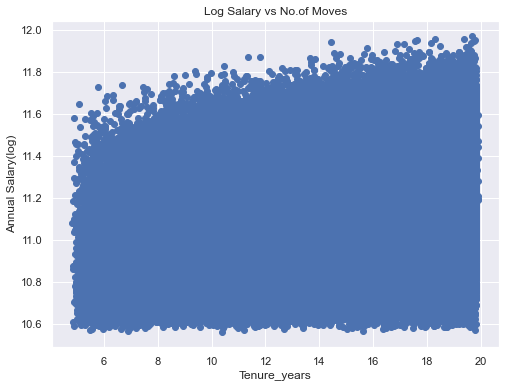

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    data_upd['Tenure_years'],
    data_upd['log_salary'])

plt.title('Log Salary vs No.of Moves')
plt.xlabel('Tenure_years')
plt.ylabel('Annual Salary(log)')

plt.show()

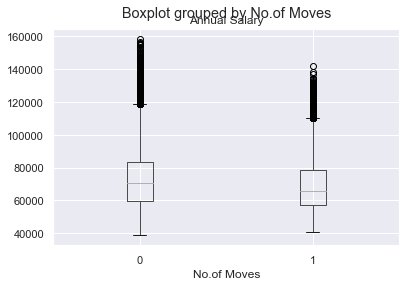

In [35]:
# Because No.of Moves is effectively a binary variable and; Scatter plots aren't the best visualization for binary predictors, 
# I'll visualize this r/ship Log Salary and No.of Moves using boxplot

import matplotlib.pyplot as plt

data_upd.boxplot(column='Annual Salary', by='No.of Moves')
plt.show()

In [37]:
# From the above box plot it is evident that -The salary distributions for employees with and without recorded position moves 
# are very similar, suggesting that the number of recorded moves alone is not a strong predictor of salary."

# This is also supported by the correlation of -0.067

In [38]:
# Checking the values count for employees with a move and those without

data_upd['No.of Moves'].value_counts()

0    207071
1     33054
Name: No.of Moves, dtype: int64

In [39]:
# this variable is very imbalanced,
# It contains only two values
# and most of the employees have no recorded move

#### Next I'll encode categorical variables using dummies

In [40]:
# First, I'll create dummy variables

data_with_dummies = pd.get_dummies(data_upd, drop_first=True)

In [41]:
data_with_dummies.head()

,Tenure_years,No.of Moves,Annual Salary,log_salary,Gender_M,Position_Engineer,Position_Manager,Position_Senior Engineer,Position_Senior Staff,Position_Staff,Position_Technique Leader
0,18.414784,0,88958,11.395920,1,0,0,1,0,0,0
1,19.008898,0,72527,11.191714,0,0,0,0,0,1,0
2,9.826146,0,77935,11.263630,1,0,0,0,0,1,0
3,11.310061,1,99651,11.509429,0,0,0,0,1,0,0
4,17.645448,0,84672,11.346540,0,0,0,1,0,0,0


In [42]:
# Next, I'll reorder the columns to facilitate my work; I'll make log-salary the first column

data_with_dummies.columns.values

array(['Tenure_years', 'No.of Moves', 'Annual Salary', 'log_salary',
       'Gender_M', 'Position_Engineer', 'Position_Manager',
       'Position_Senior Engineer', 'Position_Senior Staff',
       'Position_Staff', 'Position_Technique Leader'], dtype=object)

In [43]:
cols = ['log_salary', 'Tenure_years', 'No.of Moves', 'Annual Salary',
       'Gender_M', 'Position_Engineer', 'Position_Manager',
       'Position_Senior Engineer', 'Position_Senior Staff',
       'Position_Staff', 'Position_Technique Leader']

In [44]:
data_preprocessed = data_with_dummies[cols]
data_preprocessed.head()

,log_salary,Tenure_years,No.of Moves,Annual Salary,Gender_M,Position_Engineer,Position_Manager,Position_Senior Engineer,Position_Senior Staff,Position_Staff,Position_Technique Leader
0,11.395920,18.414784,0,88958,1,0,0,1,0,0,0
1,11.191714,19.008898,0,72527,0,0,0,0,0,1,0
2,11.263630,9.826146,0,77935,1,0,0,0,0,1,0
3,11.509429,11.310061,1,99651,0,0,0,0,1,0,0
4,11.346540,17.645448,0,84672,0,0,0,1,0,0,0


In [ ]:
# Dropped the Annual Salary column with data_preprocessed.drop(['Annual Salary'])

#### Train-test split

In [66]:
# Next, as I build the model, I'll first declare the inputs and targets before train test split

targets = data_preprocessed['log_salary']

inputs = data_preprocessed.drop(
    ['log_salary', 'Annual Salary'],
    axis=1
)

In [67]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2,random_state=365) 
  
# In the above 4 new variables created, those with the suffix "train" will be used to train the model while those with "test" 
# suffix is for testing the model.

#### Create the regression

In [68]:
reg = LinearRegression() # Let reg be an instance of the linear regression class
reg.fit(x_train, y_train)

LinearRegression()

#### Check predicted values against observed values
#### One way to check the final results of the model is to plot the predicted values against the observed values.¶

In [69]:
y_hat = reg.predict(x_train)

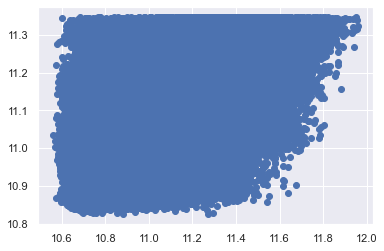

In [70]:
plt.scatter(y_train, y_hat)
plt.show()

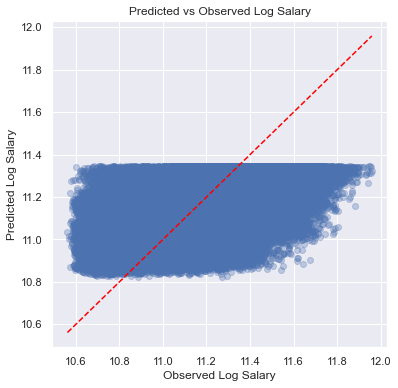

In [71]:
plt.figure(figsize=(6,6))

plt.scatter(y_train, y_hat, alpha=0.3)

# Perfect prediction line
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')

plt.xlabel('Observed Log Salary')
plt.ylabel('Predicted Log Salary')
plt.title('Predicted vs Observed Log Salary')

plt.show()

In [74]:
data_preprocessed.columns

Index(['log_salary', 'Tenure_years', 'No.of Moves', 'Annual Salary',
       'Gender_M', 'Position_Engineer', 'Position_Manager',
       'Position_Senior Engineer', 'Position_Senior Staff', 'Position_Staff',
       'Position_Technique Leader'],
      dtype='object')

In [77]:
inputs.columns

Index(['Tenure_years', 'No.of Moves', 'Gender_M', 'Position_Engineer',
       'Position_Manager', 'Position_Senior Engineer', 'Position_Senior Staff',
       'Position_Staff', 'Position_Technique Leader'],
      dtype='object')

In [73]:
reg.score(x_train, y_train)
reg.score(x_test, y_test)

0.23855195671072071

In [76]:
data_preprocessed.columns

Index(['log_salary', 'Tenure_years', 'No.of Moves', 'Annual Salary',
       'Gender_M', 'Position_Engineer', 'Position_Manager',
       'Position_Senior Engineer', 'Position_Senior Staff', 'Position_Staff',
       'Position_Technique Leader'],
      dtype='object')

In [78]:
print(reg.score(x_train, y_train))
print(reg.score(x_test, y_test))

0.2400710444161731
0.23855195671072071


In [79]:
# OBSERVATION:
# The linear regression model achieved an R² of 0.24 on both the training and test datasets. The similar performance 
# indicates that the model generalizes consistently and is not overfitting. However, the relatively low R² suggests that the 
# available predictors explain only about 24% of the variation in log salary. This indicates that additional variables, 
# such as employee performance, education, or prior experience, are likely important drivers of salary not captured in the dataset.

In [81]:
# Next, I'll run a VIF to check for multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_upd[['No.of Moves','Tenure_years']]
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif["features"] = variables.columns

In [82]:
vif

,VIF,features
0,1.12426,No.of Moves
1,1.12426,Tenure_years


In [83]:
# We see NO multicolinearity with the two variables.

In [84]:
# Next, I'll fit the model using statsmodels

import statsmodels.api as sm

X = sm.add_constant(inputs)

model = sm.OLS(targets, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     8415.
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:22:27   Log-Likelihood:                 38946.
No. Observations:              240125   AIC:                        -7.787e+04
Df Residuals:                  240115   BIC:                        -7.777e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [85]:
# These results with statsmodels are similar to those of sklearn regression with an R-squared on 0.24. It shows that the model
# explains only 24% of the variation in salary.

In [86]:
# CONCLUSION:
# This project explored the factors influencing employee salaries using multiple linear regression. After cleaning the data, 
# performing exploratory data analysis, engineering features, and encoding categorical variables, a regression model was built 
# to predict employees' log-transformed annual salaries.

# The exploratory analysis revealed that salary generally increases with job seniority. However, there was substantial variation
# in salaries within the same job position, suggesting that position alone is not sufficient to explain salary differences. 
# Tenure showed a moderate positive relationship with salary, while the number of internal moves had little to no positive 
# association with earnings.

# The final regression model achieved an R² of approximately 0.24, indicating that the selected variables explain 
# 24% of the variation in employee salaries. The similar training and testing R² values suggest that the model generalizes 
# consistently and does not suffer from overfitting. Statistical testing also showed that tenure and most job position categories
# were significant predictors of salary, whereas gender was not statistically significant in this model.

# Overall, the results demonstrate that while employee position and tenure contribute to salary prediction, a large proportion 
# of salary variation is driven by factors not available in this dataset. Variables such as education, performance ratings, 
# prior work experience, certifications, and geographical location would likely improve the model's predictive performance.

In [87]:
# KEY STEPS IN THE PROJECT

# Performed data extraction and preparation using SQL.
# Conducted exploratory data analysis to identify salary patterns and relationships.
# Applied feature engineering by creating tenure and internal movement variables.
# Encoded categorical variables using dummy variables.
# Built and evaluated a multiple linear regression model using both Scikit-learn and Statsmodels.
# Checked model assumptions and interpreted statistical outputs, including coefficients, p-values, R², and diagnostic statistics.
# Identified target leakage during model development and corrected it, resulting in a more reliable and realistic predictive model.

In [ ]:
# PERSONAL REFLECTION

# This project reinforced the importance of understanding the data before building predictive models

# Although the model explains only a modest proportion of salary variation, the analysis provides meaningful insights into the 
# factors associated with employee compensation and highlights the importance of selecting relevant features when developing 
# predictive models.